In [33]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [20]:
url = "https://raw.githubusercontent.com/SayliThukral/machine_learning/main/Social_Network_Ads.csv"
data=pd.read_csv(url)
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [21]:
X=data.iloc[:,2:4].values# only require age and salary to predict output :all row 2,4 means columns from 2 to 4 .values convert to array

In [22]:
X.shape

(400, 2)

In [23]:
Y=data.iloc[:,-1].values #take all rows but only last column

In [24]:
Y.shape

(400,)

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)

In [26]:
X_test.shape

(80, 2)

In [27]:
X_train.shape

(320, 2)

In [28]:
#since square of distance between age is very large from  estimated salary 
#.fit is used to train a ml model 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Scale training data
X_train = scaler.fit_transform(X_train)

In [29]:
# Scale test data
X_test = scaler.transform(X_test)

In [30]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_pred.shape

(80,)

In [31]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8875

In [32]:
accuracy = []
for i in range(1, 26):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    accuracy.append(accuracy_score(y_test, knn.predict(X_test)))
    print(f"Accuracy for k={i}: {accuracy[-1]}")

Accuracy for k=1: 0.8
Accuracy for k=2: 0.7875
Accuracy for k=3: 0.825
Accuracy for k=4: 0.8375
Accuracy for k=5: 0.8625
Accuracy for k=6: 0.875
Accuracy for k=7: 0.9
Accuracy for k=8: 0.8875
Accuracy for k=9: 0.8875
Accuracy for k=10: 0.875
Accuracy for k=11: 0.8875
Accuracy for k=12: 0.875
Accuracy for k=13: 0.875
Accuracy for k=14: 0.875
Accuracy for k=15: 0.875
Accuracy for k=16: 0.8875
Accuracy for k=17: 0.8875
Accuracy for k=18: 0.8875
Accuracy for k=19: 0.8875
Accuracy for k=20: 0.8875
Accuracy for k=21: 0.8875
Accuracy for k=22: 0.8875
Accuracy for k=23: 0.8875
Accuracy for k=24: 0.8875
Accuracy for k=25: 0.8875


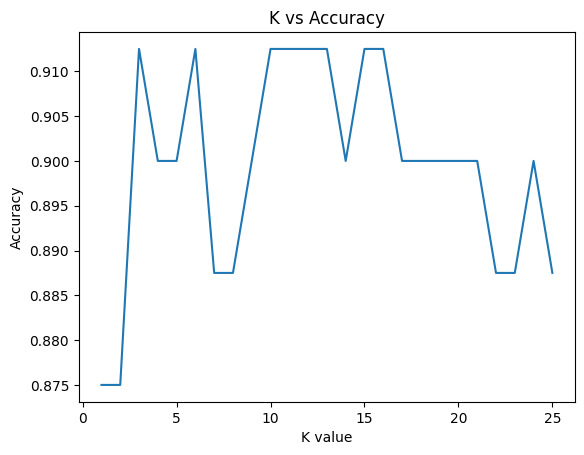

In [15]:
plt.plot(range(1, 26), accuracy)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

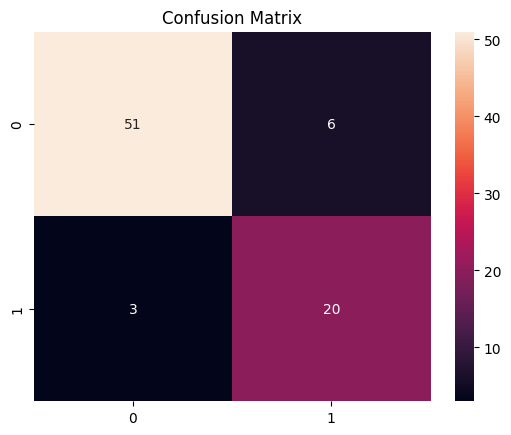

In [34]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.89      0.92        57
           1       0.77      0.87      0.82        23

    accuracy                           0.89        80
   macro avg       0.86      0.88      0.87        80
weighted avg       0.89      0.89      0.89        80

